# Assignment Code: DA-AG-018
## Anomaly Detection & Time Series | Assignment

---

## Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

**Answer:**

Anomaly Detection is the process of identifying unusual patterns or observations in data that do not conform to expected behavior. These anomalies may indicate critical incidents such as fraud, system faults, or unusual events.

There are three main types of anomalies:

**Point Anomaly:**  
A single observation that significantly deviates from the rest of the data.  
Example: A credit card transaction of ₹1,00,000 when the user normally spends ₹1,000.

**Contextual Anomaly:**  
An observation that is abnormal in a specific context but may be normal in another.  
Example: A temperature of 30°C may be normal in summer but abnormal in winter.

**Collective Anomaly:**  
A group of data points that together represent abnormal behavior even if individual points seem normal.  
Example: A sudden spike in network traffic over a period of time.

---

## Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.

**Answer:**

Isolation Forest is an anomaly detection algorithm based on decision trees. It isolates anomalies because they require fewer splits in the tree structure. It is efficient for large datasets and works well for high-dimensional data.

DBSCAN is a density-based clustering algorithm that groups points based on density. Points that do not belong to any cluster are considered noise or anomalies. It works well for datasets with clusters of varying shapes.

Local Outlier Factor (LOF) measures the local density of a data point compared to its neighbors. If a point has significantly lower density than its neighbors, it is considered an anomaly. It is useful for detecting local anomalies in datasets.

---

## Question 3: What are the key components of a Time Series? Explain each with one example.

**Answer:**

A time series consists of several components:

**Trend:**  
The long-term direction of the data (increasing or decreasing).  
Example: Increasing yearly sales of a company.

**Seasonality:**  
Regular repeating patterns over fixed periods.  
Example: Ice cream sales increasing every summer.

**Cyclic Component:**  
Fluctuations occurring over longer periods that are not strictly periodic.  
Example: Economic boom and recession cycles.

**Residual (Noise):**  
Random variation that cannot be explained by the trend or seasonality.

---

## Question 4: Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

**Answer:**

A stationary time series is one whose statistical properties such as mean, variance, and autocorrelation remain constant over time.

To test stationarity, statistical tests such as the **Augmented Dickey-Fuller (ADF) test** can be used.

If a series is non-stationary, it can be transformed into a stationary series using techniques such as:

- Differencing
- Log transformation
- Seasonal differencing
- Detrending

---

## Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models.

**Answer:**

**AR (AutoRegressive) Model:**  
Uses past values of the time series to predict future values.

**MA (Moving Average) Model:**  
Uses past forecast errors to predict future values.

**ARIMA (AutoRegressive Integrated Moving Average):**  
Combines AR and MA components with differencing to handle non-stationary data.

**SARIMA (Seasonal ARIMA):**  
Extends ARIMA to handle seasonal patterns in time series data.

**SARIMAX:**  
An extension of SARIMA that includes external variables (exogenous variables) such as weather or economic indicators.

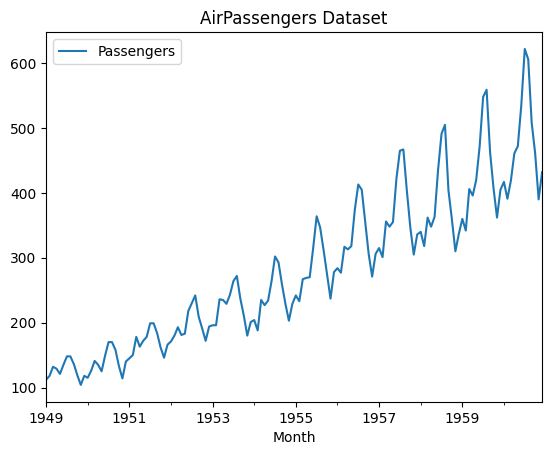

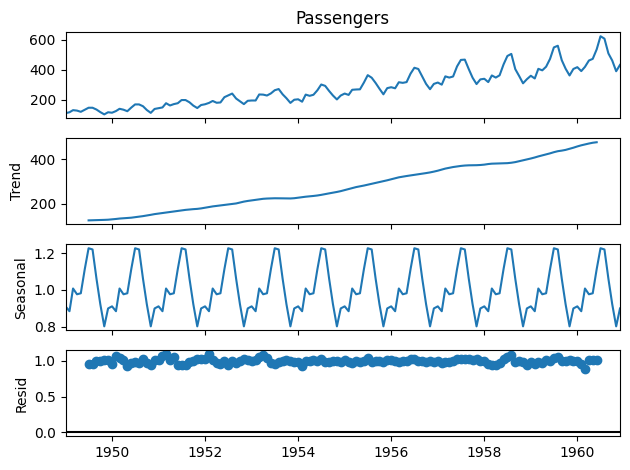

In [1]:
# Question 6
# Load AirPassengers dataset and decompose into trend, seasonality, residual

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Plot original series
data.plot(title="AirPassengers Dataset")
plt.show()

# Decompose time series
result = seasonal_decompose(data['Passengers'], model='multiplicative')

result.plot()
plt.show()

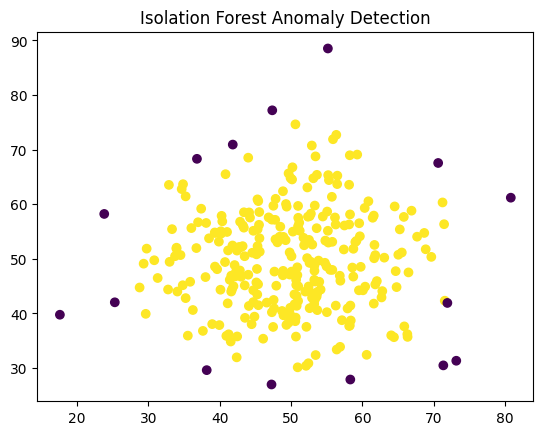

In [2]:
# Question 7
# Detect anomalies using Isolation Forest

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Simulated taxi fare data
np.random.seed(42)
X = np.random.normal(50, 10, (300, 2))

model = IsolationForest(contamination=0.05)
pred = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=pred)
plt.title("Isolation Forest Anomaly Detection")
plt.show()

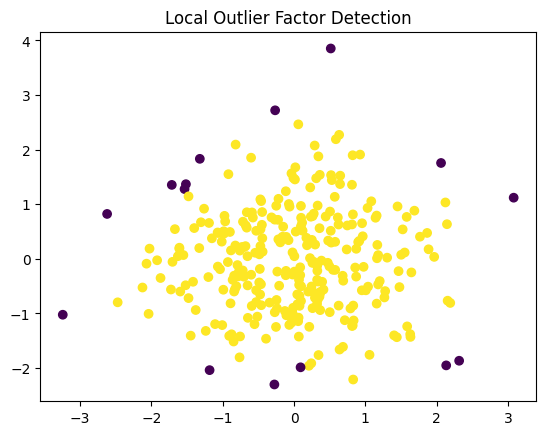

In [3]:
# Question 9
# Local Outlier Factor anomaly detection

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)
X = np.random.normal(0, 1, (300,2))

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels = lof.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Local Outlier Factor Detection")
plt.show()

## Question 10: Real-Time Energy Demand Monitoring

To detect anomalies in real-time streaming energy data, anomaly detection models such as Isolation Forest or Local Outlier Factor can be applied. Isolation Forest is efficient for large datasets and works well for real-time anomaly detection because it isolates abnormal points quickly.

For forecasting short-term energy demand, SARIMAX would be suitable because it allows the inclusion of external variables such as weather conditions, region, and time of day, which significantly affect energy usage.

Model performance can be validated using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and cross-validation on historical data. Continuous monitoring dashboards can be built to track prediction errors and detect model drift.

This solution helps businesses by predicting energy demand accurately and identifying abnormal spikes or drops in real time. It allows grid operators to manage supply efficiently, prevent outages, and optimize energy distribution.

In [4]:
# Example workflow for anomaly detection + forecasting

import numpy as np
from sklearn.ensemble import IsolationForest

# Simulated energy usage data
energy_usage = np.random.normal(1000, 100, 500)

energy_usage = energy_usage.reshape(-1,1)

model = IsolationForest(contamination=0.03)
labels = model.fit_predict(energy_usage)

print("Anomalies detected:", sum(labels == -1))

Anomalies detected: 14


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_5053/3175767422.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(data.index[-1], periods=13, freq='M')[1:], forecast, label="Forecast")


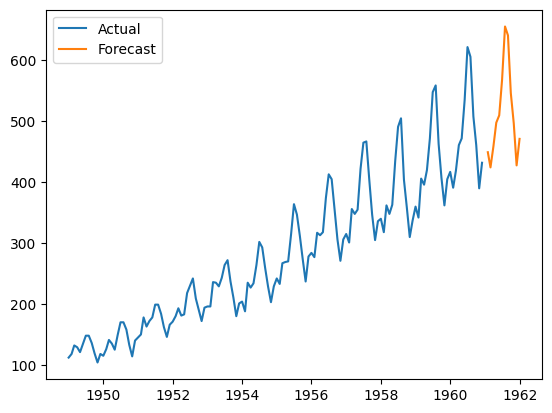

In [5]:
# Question 8
# Train SARIMA model and forecast next 12 months

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

model = SARIMAX(data['Passengers'], order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()

forecast = results.forecast(12)

plt.plot(data.index, data['Passengers'], label="Actual")
plt.plot(pd.date_range(data.index[-1], periods=13, freq='M')[1:], forecast, label="Forecast")
plt.legend()
plt.show()